In [ ]:
import os
import json
import sys
import numpy as np
import matplotlib.pyplot as plt

# Add scripts folder to path to allow importing inference_utils
sys.path.append(os.path.abspath(".."))

from scripts.fpga.inference_utils import clip

# --- CONFIGURATION ---
# Set the path to the folder you copied back from the FPGA
RESULTS_DIR = "../results/fpga/inference_ResidualScaleHyperpriorDPUWrapper_pt_2021-11-21_13-58-02"

if not os.path.exists(RESULTS_DIR):
    raise FileNotFoundError(f"Results directory '{RESULTS_DIR}' does not exist.")
recons_dir = os.path.join(RESULTS_DIR, "reconstructions")
if not os.path.exists(recons_dir):
    raise FileNotFoundError(f"Reconstructions directory '{recons_dir}' does not exist.")

Analyzing results from: ../results/fpga/inference_ResidualScaleHyperpriorDPUWrapper_pt_2021-11-21_13-58-02


In [8]:
# 1. Print Execution Summary
metrics_path = os.path.join(RESULTS_DIR, "metrics.json")
log_path = os.path.join(RESULTS_DIR, "inference.log")

# Check Log Header for Model Info
if os.path.exists(log_path):
    print("\n--- Run Info ---")
    with open(log_path, "r") as f:
        # Print first 5 lines (Timestamp, Model, Data info)
        for i in range(5):
            line = f.readline()
            if not line:
                break
            print(line.strip())

# Print Metrics
if os.path.exists(metrics_path):
    with open(metrics_path, "r") as f:
        metrics = json.load(f)
    print("\n--- Final Metrics ---")
    print(json.dumps(metrics, indent=4))
else:
    print("\nmetrics.json not found in result directory.")


--- Run Info ---
Starting Hybrid Inference at 2021-11-21_13-58-02.
Loading graph from models/ResidualScaleHyperpriorDPUWrapper_pt/ResidualScaleHyperpriorDPUWrapper_pt.xmodel...
Found 4 DPU subgraphs and 4 CPU subgraphs, for a total of 12.
Identified DPU subgraph: subgraph_ResidualScaleHyperpriorDPUWrapper__ResidualScaleHyperpriorDPUWrapper_Sequential_h_s__ConvTranspose2d_0__ret_41 with input shape (1, 2, 2, 256)
Identified DPU subgraph: subgraph_ResidualScaleHyperpriorDPUWrapper__ResidualScaleHyperpriorDPUWrapper_Sequential_h_a__Conv2d_0__ret_35 with input shape (1, 16, 16, 256)

--- Final Metrics ---
{
    "Noisy": {
        "bpp": 2.7720255946629004,
        "mse": 16158.51123046875,
        "psnr": 8.547260375718704
    },
    "ADAM": {
        "bpp": 2.7720255946629004,
        "mse": 6620.756396484375,
        "psnr": 12.815879299505479
    },
    "MERLIN": {
        "bpp": 2.7720255946629004,
        "mse": 8199.004443359376,
        "psnr": 11.972852446074544
    }
}


Loading reconstruction arrays...
vis_noisy shape: (5, 256, 256), vis_recon shape: (5, 256, 1), vis_adam shape: (5, 256, 256, 1), vis_merlin shape: (5, 256, 256, 1)
Loaded 5 patches for visualization.
Figure saved to: ../results/fpga/inference_ResidualScaleHyperpriorDPUWrapper_pt_2021-11-21_13-58-02/recreated_visual_comparison.png


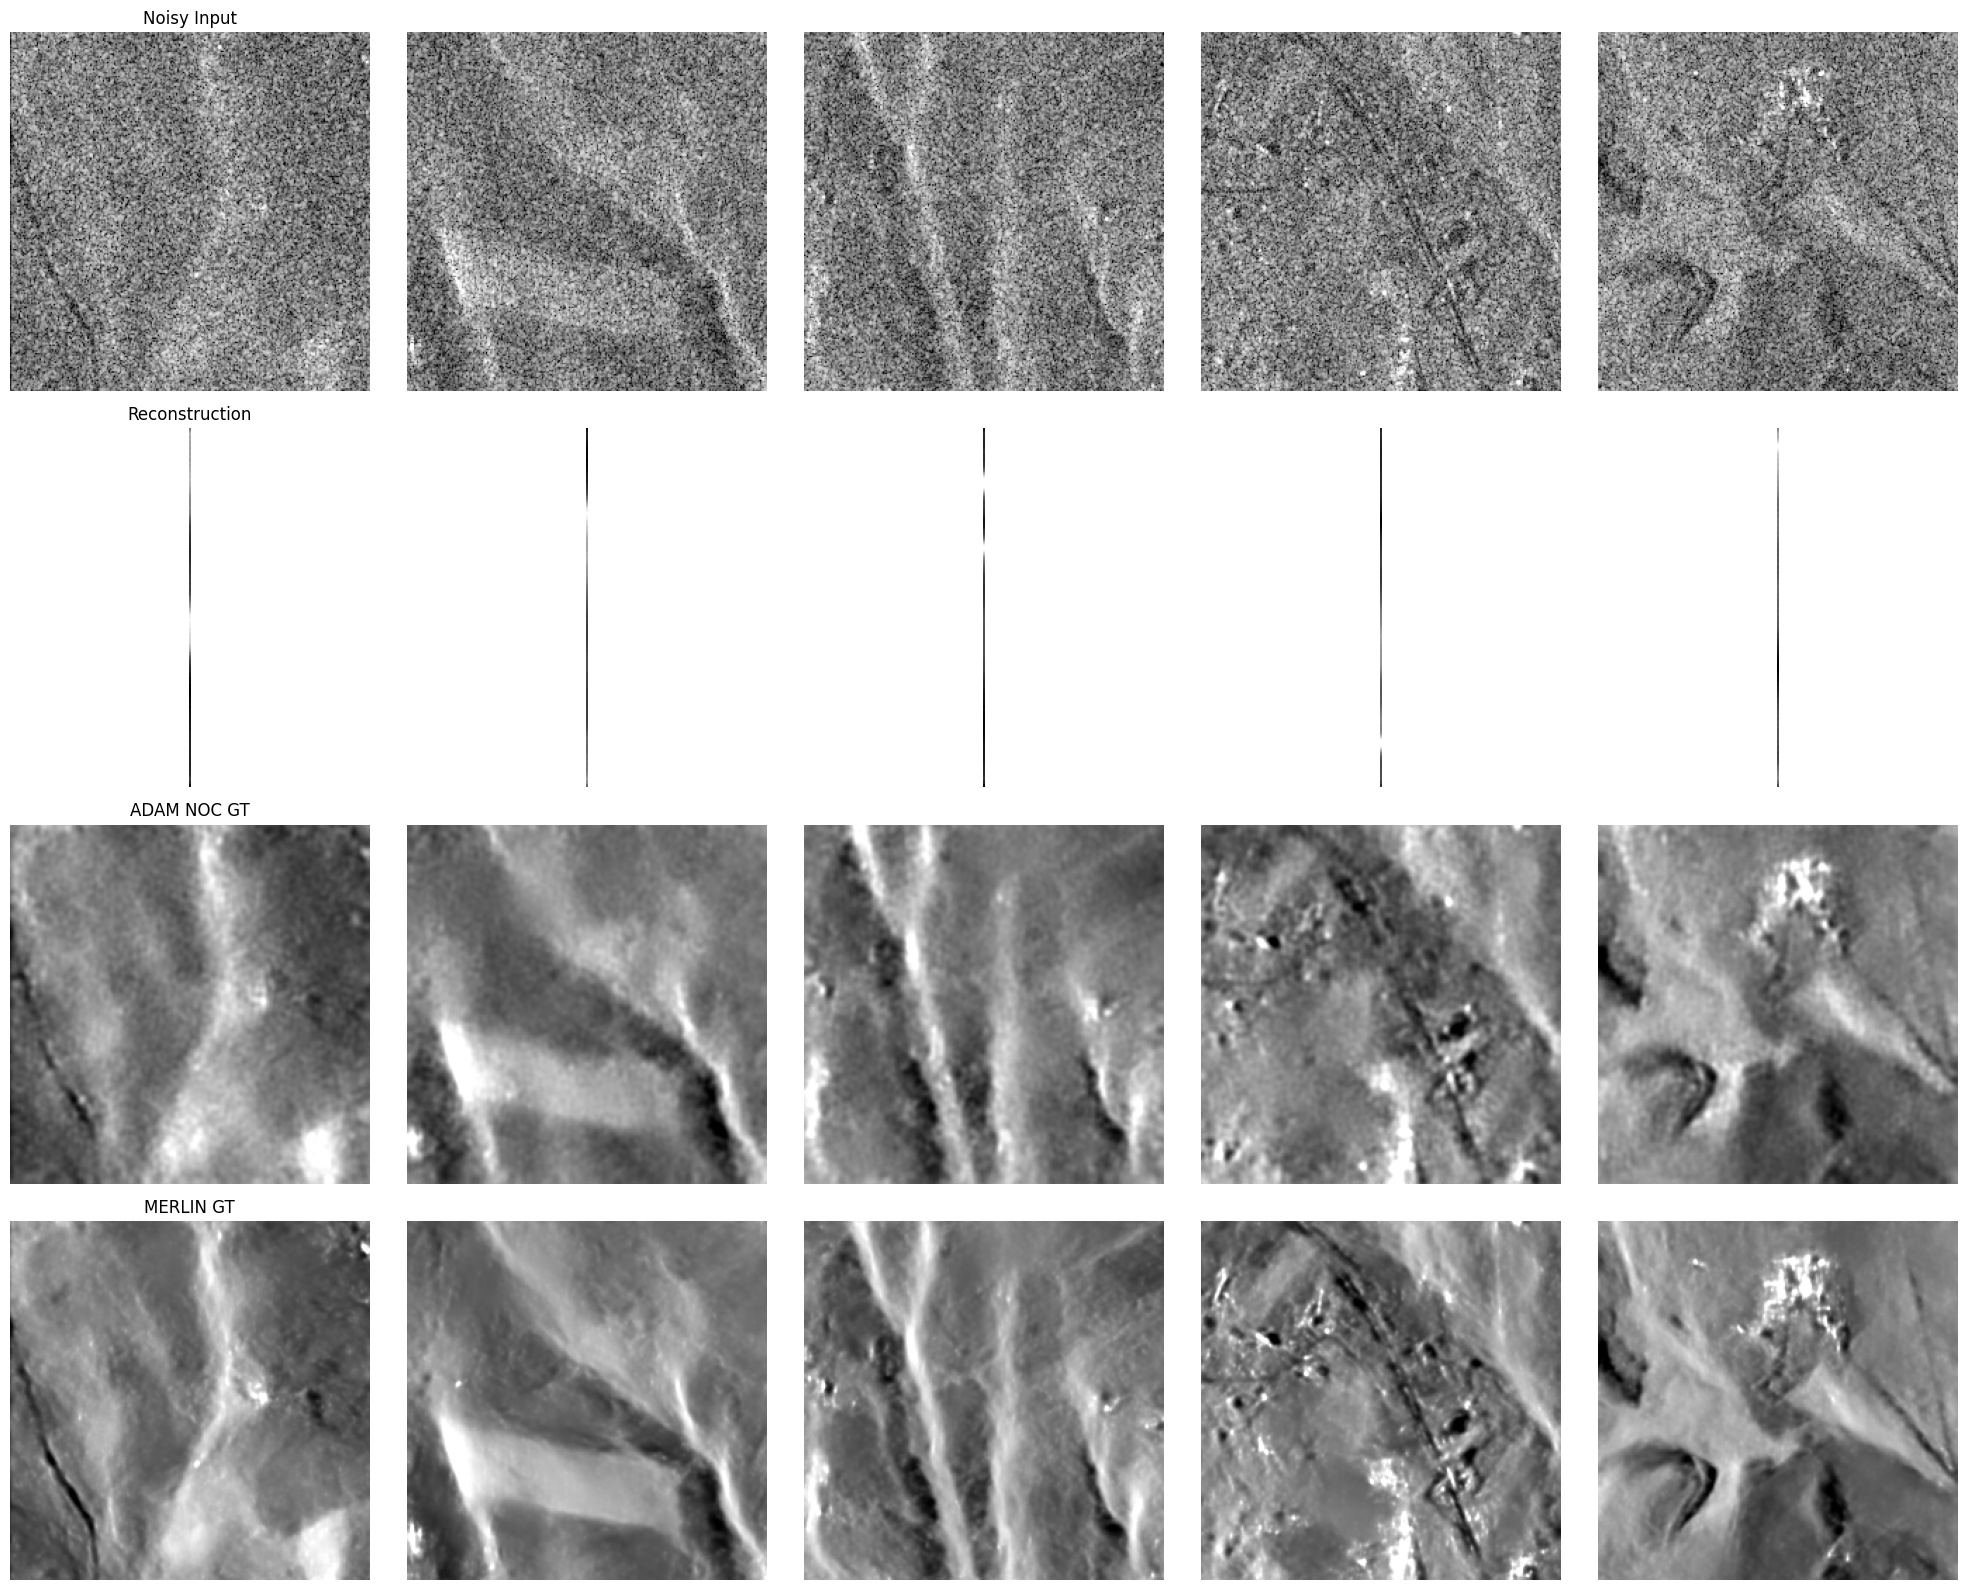

In [ ]:
# 2. Reconstruct Visualization from Raw Arrays
recons_dir = os.path.join(RESULTS_DIR, "reconstructions")

if os.path.exists(recons_dir):
    print("Loading reconstruction arrays...")

    vis_noisy = np.load(os.path.join(recons_dir, "vis_noisy.npy"))
    vis_recon = np.load(os.path.join(recons_dir, "vis_recon.npy"))
    vis_adam = np.load(os.path.join(recons_dir, "vis_adam.npy"))
    vis_merlin = np.load(os.path.join(recons_dir, "vis_merlin.npy"))

    print(f"Loaded {len(vis_noisy)} patches for visualization.")

    # --- Visualization Logic (Inline to ensure correctness) ---
    num_patches = len(vis_noisy)
    N = min(5, num_patches)

    fig, axes = plt.subplots(4, N, figsize=(4 * N, 16))
    if N == 1:
        axes = axes.reshape(4, 1)

    for i in range(N):
        # Clip individual patches (not the whole batch)
        noisy_disp = clip(vis_noisy[i])
        recon_disp = clip(vis_recon[i])
        adam_disp = clip(vis_adam[i])
        merlin_disp = clip(vis_merlin[i])

        # Row 0: Original Noisy (LogI)
        axes[0, i].imshow(noisy_disp, cmap="gray")
        axes[0, i].axis("off")
        if i == 0:
            axes[0, i].set_title("Noisy Input")

        # Row 1: Reconstruction (LogI)
        axes[1, i].imshow(recon_disp, cmap="gray")
        axes[1, i].axis("off")
        if i == 0:
            axes[1, i].set_title("Reconstruction")

        # Row 2: ADAM NOC GT (LogI)
        axes[2, i].imshow(adam_disp, cmap="gray")
        axes[2, i].axis("off")
        if i == 0:
            axes[2, i].set_title("ADAM NOC GT")

        # Row 3: MERLIN GT (LogI)
        axes[3, i].imshow(merlin_disp, cmap="gray")
        axes[3, i].axis("off")
        if i == 0:
            axes[3, i].set_title("MERLIN GT")

    plt.tight_layout()
    plt.show()

else:
    print(
        f"No 'reconstructions' folder found in {RESULTS_DIR}. Run inference with updated script to generate these."
    )